In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

np.set_printoptions(precision=3)
np.set_printoptions(suppress=True)

In [2]:
df = pd.read_csv("../../data/games_augmented.csv", index_col=0)

In [3]:
df.head(n=10)

,Season,Date,HID,AID,OddsH,OddsA,OddsD,H,A,D,HS,AS,Special,H_PEN,A_PEN,H_MAJ,A_MAJ,H_PPG,A_PPG,H_SHG,A_SHG,H_SV,A_SV,H_PIM,A_PIM,H_SOG,A_SOG,H_BLK_S,A_BLK_S,H_HIT,A_HIT,H_BLK,A_BLK,H_FO,A_FO,H_P1,A_P1,H_P2,A_P2,H_P3,A_P3,H_OT,A_OT,H_SO,A_SO,elo_lambda_H,elo_lambda_A,elo_prob_H,elo_prob_A,elo_prob_D,enough_games,wm_H,wm_A,wm_HS,wm_AS,wm_HD,wm_AD,wm_H_PIM,wm_A_PIM,wm_H_PPG,wm_A_PPG,wm_H_SHG,wm_A_SHG,wm_H_SV,wm_A_SV,wm_H_SOG,wm_A_SOG,wm_H_recv,wm_A_recv,wm_HS_recv,wm_AS_recv,wm_HD_recv,wm_AD_recv,wm_H_PIM_recv,wm_A_PIM_recv,wm_H_PPG_recv,wm_A_PPG_recv,wm_H_SHG_recv,wm_A_SHG_recv,wm_H_SV_recv,wm_A_SV_recv,wm_H_SOG_recv,wm_A_SOG_recv,m_H,m_A,m_HS,m_AS,m_HD,m_AD,m_H_PIM,m_A_PIM,m_H_PPG,m_A_PPG,m_H_SHG,m_A_SHG,m_H_SV,m_A_SV,m_H_SOG,m_A_SOG,m_H_MAJ,m_A_MAJ,m_H_PEN,m_A_PEN,m_H_recv,m_A_recv,m_HS_recv,m_AS_recv,m_HD_recv,m_AD_recv,m_H_PIM_recv,m_A_PIM_recv,m_H_PPG_recv,m_A_PPG_recv,m_H_SHG_recv,m_A_SHG_recv,m_H_SV_recv,m_A_SV_recv,m_H_SOG_recv,m_A_SOG_recv,m_H_MAJ_recv,m_A_MAJ_recv,m_H_PEN_recv,m_A_PEN_recv,rest_days_H,rest_days_A,m_H_penalties,m_A_penalties,m_H_penalties_recv,m_A_penalties_recv,m_H_net_goals,m_A_net_goals,m_H_shooting_pct,m_A_shooting_pct,m_H_save_pct,m_A_save_pct,m_H_pp_succ,m_A_pp_succ,m_H_pk_succ,m_A_pk_succ,m_H_sh_succ,m_A_sh_succ,rest_days_diff,net_goals_diff,penalties_diff,penalties_recv_diff,m_H_pdo,m_A_pdo,pp_diff,pk_diff,pdo_diff
0,1989,1989-09-19,5,12,0.0,0.0,0.0,True,False,False,4,2,NaN,5,5,0,0,2.0,1.0,0.0,0.0,26.0,30.0,10,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,2.0,0.0,2.0,1.0,NaN,NaN,NaN,NaN,6.250000,5.000000,0.587644,0.299760,0.112597,0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,1.000000,1.00,0.0,0.0,0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,1989,1989-09-19,15,13,0.0,0.0,0.0,False,True,False,1,3,NaN,4,7,0,0,1.0,1.0,0.0,0.0,28.0,23.0,8,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,6.250000,5.000000,0.587644,0.299760,0.112597,0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,1.000000,1.00,0.0,0.0,0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
2,1989,1989-09-19,19,4,0.0,0.0,0.0,True,False,False,7,3,NaN,1,3,0,0,0.0,0.0,0.0,1.0,26.0,31.0,2,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,2.0,1.0,5.0,0.0,NaN,NaN,NaN,NaN,6.250000,5.000000,0.587644,0.299760,0.112597,0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,1.000000,1.00,0.0,0.0,0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
3,1989,1989-09-19,16,3,0.0,0.0,0.0,True,False,False,6,3,NaN,3,5,0,0,0.0,0.0,0.0,1.0,26.0,40.0,6,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,2.0,2.0,3.0,0.0,NaN,NaN,NaN,NaN,6.250000,5.000000,0.587644,0.299760,0.112597,0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [4]:
# forget first 1000 rows
df = df[1000:]
# limit season to 2002 
df = df[df["Season"] <= 2002]

df["enough_games"] = df["enough_games"].astype(int)

In [5]:
# compute match results
y = df[["H", "A", "D"]].idxmax(axis=1)

# if the match ended with OT (over-time) or PS (nájezdy) consider it a draw
y[(df["Special"] == "OT") | (df["Special"] == "PS")] = "D"

# remove match stats
x_columns = list(df.columns[42:])

# optional: make predictions based on Odds
# x_columns += ["OddsA", "OddsH", "OddsD"]

X = df[x_columns].dropna(axis=1)

In [6]:
X

,elo_lambda_H,elo_lambda_A,elo_prob_H,elo_prob_A,elo_prob_D,enough_games,wm_H,wm_A,wm_HS,wm_AS,wm_HD,wm_AD,wm_H_PIM,wm_A_PIM,wm_H_recv,wm_A_recv,wm_HS_recv,wm_AS_recv,wm_HD_recv,wm_AD_recv,wm_H_PIM_recv,wm_A_PIM_recv,m_H,m_A,m_HS,m_AS,m_HD,m_AD,m_H_PIM,m_A_PIM,m_H_MAJ,m_A_MAJ,m_H_PEN,m_A_PEN,m_H_recv,m_A_recv,m_HS_recv,m_AS_recv,m_HD_recv,m_AD_recv,m_H_PIM_recv,m_A_PIM_recv,m_H_MAJ_recv,m_A_MAJ_recv,m_H_PEN_recv,m_A_PEN_recv,rest_days_H,rest_days_A,m_H_penalties,m_A_penalties,m_H_penalties_recv,m_A_penalties_recv,m_H_net_goals,m_A_net_goals,m_H_shooting_pct,m_A_shooting_pct,m_H_save_pct,m_A_save_pct,m_H_pp_succ,m_A_pp_succ,m_H_pk_succ,m_A_pk_succ,m_H_sh_succ,m_A_sh_succ,rest_days_diff,net_goals_diff,penalties_diff,penalties_recv_diff,m_H_pdo,m_A_pdo,pp_diff,pk_diff,pdo_diff
1000,3.463861,2.400585,0.589575,0.256020,0.154404,1,0.092857,0.092857,0.421428,-0.178572,-0.085714,0.014286,1.192859,-1.307141,-0.007143,-0.107143,0.614286,-0.685714,-0.085714,0.014286,3.364286,1.564286,0.518519,0.407407,3.074074,2.518518,0.148148,0.259259,12.111111,12.259259,0.333333,0.444444,4.407407,4.777778,0.333333,0.333333,2.592592,2.555556,0.148148,0.259259,14.185185,14.814815,0.592593,0.518519,4.148148,5.111111,14,19,4.740741,5.222222,4.740741,5.629630,0.481482,-0.037037,0.087460,0.076233,0.927386,0.929878,0.109375,0.164474,0.859375,0.858156,0.007813,0.028369,-5,0.518519,-0.481481,-0.888889,1.014846,1.006111,-0.055099,0.001219,0.008735
1001,4.034625,2.302261,0.686904,0.183263,0.129833,1,0.092857,0.092857,0.421428,0.921428,0.114286,0.114286,1.292858,-3.707142,-0.207143,-0.207143,-0.585714,0.514286,0.114286,0.114286,-2.835713,0.264286,0.464286,0.370370,2.750000,3.111111,0.321429,0.296296,10.500000,9.185185,0.250000,0.259259,4.107143,3.444444,0.214286,0.333333,1.892857,3.555556,0.321429,0.296296,8.642858,10.185185,0.142857,0.296296,3.928571,3.666667,19,19,4.357143,3.703704,4.071429,3.962963,0.857143,-0.444444,0.082002,0.099881,0.931964,0.903030,0.140351,0.140187,0.901639,0.840000,0.016393,0.090000,0,1.301587,0.653439,0.108466,1.013966,1.002911,0.000164,0.061639,0.011055
1002,2.833780,2.223912,0.516103,0.307397,0.176500,1,-0.007143,-0.007143,-0.178572,-0.278572,0.114286,0.014286,-0.507142,-6.107142,-0.107143,-0.007143,-0.585714,0.314286,0.114286,0.014286,-0.035714,-5.235714,0.321429,0.428571,2.071429,2.607143,0.214286,0.142857,9.357142,7.785714,0.250000,0.250000,3.571429,2.964286,0.464286,0.428571,2.357143,2.500000,0.214286,0.142857,12.357142,7.964286,0.392857,0.178571,4.250000,3.000000,15,19,3.821429,3.214286,4.642857,3.178571,-0.285714,0.107143,0.070218,0.000000,0.931178,0.919633,0.115385,0.123596,0.841121,0.977778,0.028037,0.022222,-4,-0.392857,0.607143,1.464286,1.001396,0.919633,-0.008211,-0.136656,0.081764
1003,3.279842,3.133951,0.442168,0.397151,0.160681,1,-0.207143,-0.007143,-0.578572,0.121428,0.214286,0.014286,-2.107142,2.292858,-0.007143,-0.007143,0.014286,0.214286,0.214286,0.014286,0.164287,-1.235714,0.346154,0.480000,2.615385,3.640000,0.153846,0.160000,11.692307,14.720000,0.423077,0.600000,4.115385,3.880000,0.500000,0.360000,3.115385,2.920000,0.153846,0.160000,11.538462,12.720000,0.269231,0.520000,4.115385,3.880000,19,14,4.538462,4.480000,4.384615,4.400000,-0.500000,0.720000,0.081437,0.000000,0.905704,0.000000,0.000000,0.172727,1.000000,0.866071,0.000000,0.000000,5,-1.220000,0.058461,-0.015385,0.987141,0.000000,-0.172727,0.133929,0.987141
1004,3.439697,2.910690,0.502274,0.339203,0.158523,1,-0.107143,-0.007143,-0.278572,0.321428,-0.085714,-0.085714,-0.807141,-2.507142,0.192857,0.092857,-0.085714,-0.385714,-0.085714,-0.085714,-0.035714,5.364286,0.370370,0.535714,2.962963,3.321429,0.148148,0.071429,11.148149,9.785714,0.296296,0.357143,3.814815,3.857143,0.481481,0.392857,3.074074,2.785714,0.148148,0.071429,10.518518,18.750000,0.333333,0.821429,3.777778,5.357143,19,19,4.111111,4.214286,4.111111,6.178572,-0.111111,0.535714,0.080483,0.104730,0.000000,0.920732,0.117117,0.138728,0.846847,0.830508,0.018018,0.067797,0,-0.646825,-0.103175,-2.067461,0.080

In [7]:
y

1000    A
1001    A
1002    D
1003    A
1004    H
       ..
4782    A
4783    D
4784    H
4785    H
4786    H
Length: 3787, dtype: object

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

# X: features (2D array), y: labels (1D array)
# Example assumes you already have X and y defined

# 1. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Fit a model
model = LogisticRegression(penalty='l2', C=1.0, max_iter=10000)
model.fit(X_train, y_train)


# 3. Predict on test set
y_pred = model.predict(X_test)

# 4. Compute accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.525065963060686


In [9]:
import statsmodels.api as sm

# stepwise feature selecion based on AIC

def fit_model(X, y, columns):
    model = sm.MNLogit(y, X[columns])
    result = model.fit()
    # result = model.fit_regularized(method='l1', alpha=1.0, max_iter=10000)
    return model, result

def model_score(X, y, columns):
    try:
        model, result = fit_model(X, y, columns)
        score = result.aic
    except:
        score = np.inf
    print(f"{columns}: {score}")
    return score

def forward_selection(X, y):    
    remaining = set(X.columns)

    selected = []
    current_score, best_new_score = np.inf, np.inf
    while remaining and current_score == best_new_score:
        scores_with_candidates = []
        for candidate in remaining:
            columns = selected + [candidate]
            score = model_score(X, y, columns)
            scores_with_candidates.append((score, candidate))
        scores_with_candidates.sort()
        best_new_score, best_candidate = scores_with_candidates[0]
        if best_new_score < current_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score

    return selected

In [10]:
best_cols = forward_selection(X, y)

Optimization terminated successfully.
         Current function value: 1.053394
         Iterations 5
['m_AD_recv']: 7982.407396635306
Optimization terminated successfully.
         Current function value: 1.021027
         Iterations 5
['m_A_PEN_recv']: 7737.259926485526
Optimization terminated successfully.
         Current function value: 1.028428
         Iterations 5
['m_H_MAJ_recv']: 7793.316402036346
Optimization terminated successfully.
         Current function value: 1.086826
         Iterations 4
['wm_H']: 8235.621475762064
Optimization terminated successfully.
         Current function value: 1.093168
         Iterations 4
['wm_AS']: 8283.651700008033
Optimization terminated successfully.
         Current function value: 1.016462
         Iterations 5
['m_A_pk_succ']: 7702.679910931852
Optimization terminated successfully.
         Current function value: 1.086364
         Iterations 4
['wm_H_recv']: 8232.119465659243
Optimization terminated successfully.
         Current f

In [11]:
model, result = fit_model(X_train, y_train, best_cols)
probs = model.predict(result.params, X_test[best_cols])
y_pred = np.array(["A", "D", "H"])[probs.argmax(axis=1)]
acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)
print(best_cols)

Optimization terminated successfully.
         Current function value: 0.977445
         Iterations 5
Accuracy: 0.5316622691292876
['elo_prob_H', 'net_goals_diff', 'pdo_diff', 'm_H_recv', 'elo_lambda_A', 'rest_days_A', 'm_H_PIM']


In [12]:
vars = model.predict(result.params, X_test[best_cols], which='var')
vars.max(axis=0)
probs.min(axis=0)

array([0.055, 0.096, 0.118])

(array([[ 73., 174., 236., 152.,  71.,  25.,  19.,   5.,   3.,   0.],
        [ 10., 484., 264.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  1.,   7.,  23.,  47.,  92., 186., 186., 133.,  70.,  13.]]),
 array([0.055, 0.133, 0.211, 0.29 , 0.368, 0.446, 0.524, 0.602, 0.68 ,
        0.758, 0.836]),
 <a list of 3 BarContainer objects>)

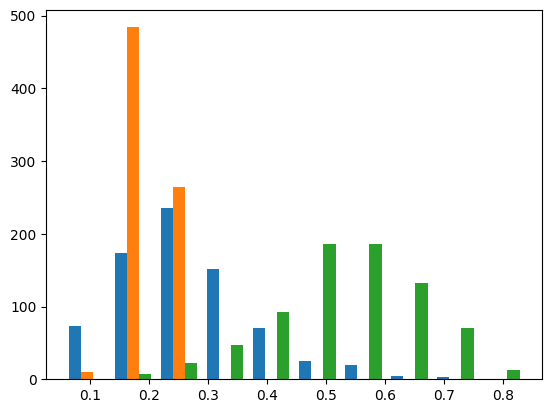

In [13]:
plt.hist(probs, bins=10)

(array([[  8.,  18.,  38.,  52.,  73.,  77., 130., 121., 107., 134.],
        [  0.,   1.,   8.,  24., 117., 451., 133.,  24.,   0.,   0.],
        [  0.,   0.,   1.,   2.,   4.,  11.,  27.,  51., 116., 546.]]),
 array([0.052, 0.072, 0.092, 0.111, 0.131, 0.151, 0.171, 0.191, 0.21 ,
        0.23 , 0.25 ]),
 <a list of 3 BarContainer objects>)

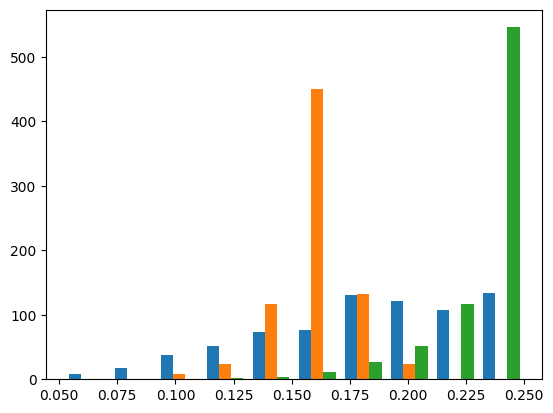

In [14]:
plt.hist(vars, bins=10)

In [33]:
class MatchOutcomeModel:
    def __init__(self):
        self.fitted = False
        self.x_columns = []
        self.last_len_df = 0

    def predict(self, opps):

        if not self.fitted:
            # Set zeros
            opps["prob_home_win"] = 0.0
            opps["prob_away_win"] = 0.0
            opps["prob_draw"] = 0.0

        X = opps[self.x_columns]
        probs = self.mnlogit.predict(self.mnlogit_result.params, X, which='mean') # probabilities in order HAD
        vars = self.mnlogit.predict(self.mnlogit_result.params, X, which='var') # probabilities in order HAD

        # TODO: investigate why it works without doing this
        # Zero-out draw when it has zero odds
        #mask = opps["OddsD"] == 0
        #probs[mask, 1] = 0.0
        #probs /= probs.sum(axis=1, keepdims=True)

        # TODO: implement proper confidence intervals
#            probs -= 0.2 * vars

        opps["prob_home_win"] = probs[:, 2]
        opps["prob_away_win"] = probs[:, 0]
        opps["prob_draw"] = probs[:, 1]

        return opps

    def increment(self, df):

        self.data = df
        if len(df) < 2000:
            return
        
        if len(df) < self.last_len_df + 250:
            return
        
        self.last_len_df = len(df)
        df = df[-1000:]
        df = df[self.x_columns]

        # compute match results
        y = df[["H", "A", "D"]].idxmax(axis=1)
        y = y.astype("category")
        y = y.cat.set_categories(["A", "D", "H"])
        X = df[self.x_columns].to_numpy()


        self.mnlogit = sm.MNLogit(y, X)
        self.mnlogit_result = self.mnlogit.fit_regularized(disp=False,
                                                           method='l1',
                                                           alpha=0.01)
        self.fitted = True

class TreeOutcomeModel:
    def __init__(self):
        self.tree = XGBClassifier(
            booster="gblinear",            
            objective="multi:softprob",
            num_class=3,
            n_estimators=50,
            learning_rate=0.1,
        )
        self.last = 0
        self.fitted = False

    def predict(self, opps):
        if not self.fitted:
            # Set zeros
            opps["prob_home_win"] = 0.0
            opps["prob_away_win"] = 0.0
            opps["prob_draw"] = 0.0
            return opps

        preds = self.tree.predict_proba(opps[self.x_columns])

        opps["prob_home_win"] = preds[:, 1]
        opps["prob_away_win"] = preds[:, 0]

        if preds.shape[1] < 3:
            opps["prob_draw"] = 0.0
        else:
            opps["prob_draw"] = preds[:, 2]

        opps["var_home_win"] = np.zeros_like(opps["prob_home_win"])
        opps["var_away_win"] = np.zeros_like(opps["prob_home_win"])
        opps["var_draw"] = np.zeros_like(opps["prob_home_win"])

        return opps

    def increment(self, df):
        if len(df) < 2000:
            return
        if len(df) < self.last + 500:
            return
        self.last = len(df)
        print(self.last)
        df.to_csv("debug_tree_data.csv", index=False)

        df = df[-1000:]
        X = df[self.x_columns]
        outcome = df[["H", "A", "D"]].idxmax(axis=1)
        labels = outcome.unique()
        y = outcome.map({"A": 0, "D": 2, "H": 1})

        self.tree.fit(X, y)
        self.fitted = True


from functools import partial
import pandas as pd
import numpy as np


class MeanFeaturesTracker:
    def __init__(self, cols: list, prefix: str = "m_", mean_normalize: bool = True):
        self.features = {} # team_id -> features

        # Set stats FOR/against
        # (function, column in game data, feature name in output (w.out prefix))
        self.flags = [(partial(self.update_mean, against=False), col, col) for col in cols]
        self.flags += [(partial(self.update_mean, against=True), col, col + "_recv") for col in cols]

        self.prefix = prefix
        self.mean_normalize = mean_normalize

        self.n_games = {} # team_id -> number of games played in the season
        self.means = np.zeros(2 * len(cols)) # season means for normalization
        
    def team_games_played(self, team_id: int) -> int:
        return self.n_games.get(team_id, 0)
    
    def initialize_team_data(self, team_id: int):
        """
            set ftrs/counters for a new team
        """
        self.features[team_id] = [0.0 for _ in range(len(self.flags))]
        self.n_games[team_id] = 0

    def team_feature_vector(self, team_id: int) -> np.ndarray:
        if team_id in self.features:
            return np.array(self.features[team_id], dtype=np.float32) - self.means
        else:
            return np.array([0.0 for _ in range(len(self.flags))], dtype=np.float32)
        
    def predict(self, game_data: pd.DataFrame) -> pd.DataFrame:
        # Create separate feature columns for home and away team means
        for i, (_, col, ft_name) in enumerate(self.flags):
            home_ftrs = game_data["HID"].apply(lambda hid: self.team_feature_vector(hid)[i])
            away_ftrs = game_data["AID"].apply(lambda aid: self.team_feature_vector(aid)[i])
            
            game_data[f"{self.prefix}H{ft_name}"] = home_ftrs
            game_data[f"{self.prefix}A{ft_name}"] = away_ftrs
        
        return game_data

    def increment(self, inc: pd.DataFrame):
        for _, row in inc.iterrows():
            home_id = row["HID"]
            away_id = row["AID"]

            if home_id not in self.features:
                self.initialize_team_data(home_id)
            if away_id not in self.features:
                self.initialize_team_data(away_id)

            # Update Home team features for team #home_id
            prefix = "H"
            for feature_id, (update_fun, col, _) in enumerate(self.flags):
                update_fun(home_id, feature_id, prefix, col, game_data=row)

            # Update Away team features for team #away_id
            prefix = "A"
            for feature_id, (update_fun, col, _) in enumerate(self.flags):
                update_fun(away_id, feature_id, prefix, col, game_data=row)

            self.n_games[home_id] += 1
            self.n_games[away_id] += 1

            # update season means for normalization
            features = np.array(list(self.features.values()), dtype=np.float32)
            if self.mean_normalize:
                self.means = np.mean(features, axis=0)

    def update_mean(self, team_id: int, feature_id: int, prefix: str, col: str,
                    against : bool, game_data: pd.Series):

        # The _against flags signals we track features of the opposing teams
        # i.e. update_mean(x, goals) ... tracks mean goals, with against it tracks mean goals conceded.
        # m_H_recv <- loss rate, etc.
        if against:
            # Switch prefixes to get opponent stats
            prefix = "A" if prefix == "H" else "H"

        if col != "D":
            col = f"{prefix}{col}"

        n_games = self.n_games.get(team_id, 0)
        current_mean = self.features[team_id][feature_id]
        updated_mean = (current_mean * n_games + game_data[col]) / (n_games + 1)
        self.features[team_id][feature_id] = updated_mean
        
    
    def reset(self):
        self.features = {}
        self.n_games = {}


class WindowMeanFeaturesTracker(MeanFeaturesTracker):
    def __init__(self, cols: list, window_size: int = 10, prefix: str = "wm_"):
        super().__init__(cols, prefix=prefix)
        self.flags = [(partial(self.update_window_mean, against=False), col, col) for col in cols]
        self.flags += [(partial(self.update_window_mean, against=True), col,
                        col + "_recv") for col in cols]
        self.window_features = {} # team_id -> list of recent game features for rolling stats
        self.window_size = window_size
    
    def initialize_team_data(self, team_id: int):
        super().initialize_team_data(team_id)
        self.window_features[team_id] = [[] for _ in range(len(self.flags))]
            
    def update_window_mean(self, team_id: int, feature_id: int, prefix: str,
                           col: str, against : bool, game_data: pd.Series):
        if against:
            # Switch prefixes to get opponent stats
            prefix = "A" if prefix == "H" else "H"

        if col != "D":
            col = f"{prefix}{col}"

        window = self.window_features[team_id][feature_id]
        window.append(game_data[col])
        if len(window) > self.window_size:
            window.pop(0)
        
        self.features[team_id][feature_id] = np.mean(window)
    
    def reset(self):
        super().reset()
        self.window_features = {}


class RestDaysTracker():
    def __init__(self):
        self.last_game_date = {}  # team_id -> last game date

    def initialize_team_data(self, team_id: int, date: pd.Timestamp):
        self.last_game_date[team_id] = date

    def team_feature_vector(self, team_id: int, current_date: pd.Timestamp) -> int:
        if team_id in self.last_game_date:
            rest_days = (current_date - self.last_game_date[team_id]).days
            return rest_days
        else:
            return 0
        
    def predict(self, game_data: pd.DataFrame) -> pd.DataFrame:
         # TODO: does not work if game_data contains multiple days for the same team

        # Calculate rest days for home and away teams based on actual dates
        def calc_home_rest(row):
            return self.team_feature_vector(row["HID"], row["Date"])
        
        def calc_away_rest(row):
            return self.team_feature_vector(row["AID"], row["Date"])
        
        game_data["rest_days_H"] = game_data.apply(calc_home_rest, axis=1)
        game_data["rest_days_A"] = game_data.apply(calc_away_rest, axis=1)
        return game_data

    def increment(self, inc: pd.DataFrame):
        for _, row in inc.iterrows():
            home_id = row["HID"]
            away_id = row["AID"]
            game_date = row["Date"]
            
            # Update last game date for both teams
            self.last_game_date[home_id] = game_date
            self.last_game_date[away_id] = game_date
    
    def reset(self):
        self.last_game_date = {}



class ComposedFeaturesTracker:
    """
        Only seasonal features, assumes data is first passed through
        predict of MeanFeaturesTracker and RestDaysTracke
    """
    def __init__(self):
        pass

    def predict(self, df: pd.DataFrame) -> pd.DataFrame:
        df = self.add_features(df)
        return df

    def increment(self, df: pd.DataFrame):
        # no state, just compute more complex features from existing ones
        pass
    
    def add_features(self, df: pd.DataFrame) -> pd.DataFrame:
        # Handle zero division by setting to 0.0
        def safe_pd_divide(numerator, denominator):
            denom = denominator.replace({0.0: np.nan})
            result = numerator / denom
            return result.astype(float).fillna(0.0)



        summary_stats = {
            "m_H_penalties": df["m_H_PEN"] + df["m_H_MAJ"],
            "m_A_penalties": df["m_A_PEN"] + df["m_A_MAJ"],
            "m_H_penalties_recv": df["m_H_PEN_recv"] + df["m_H_MAJ_recv"],
            "m_A_penalties_recv": df["m_A_PEN_recv"] + df["m_A_MAJ_recv"],
            "m_H_net_goals" : df['m_HS'] - df['m_HS_recv'],
            "m_A_net_goals" : df['m_AS'] - df['m_AS_recv'],
        }

        # Do it like this so pd does not scream about fragmentation
        df = df.assign(**summary_stats)
        df = df.assign(
            m_H_shooting_pct = safe_pd_divide(df["m_HS"], df["m_HS"] + df["m_H_SV_recv"]),
            m_A_shooting_pct = safe_pd_divide(df["m_AS"], df["m_AS"] + df["m_A_SV_recv"]),

            m_H_save_pct = safe_pd_divide(df["m_H_SV"], df["m_H_SV"] + df["m_HS_recv"]),
            m_A_save_pct = safe_pd_divide(df["m_A_SV"], df["m_A_SV"] + df["m_AS_recv"]),

            m_H_pp_succ = safe_pd_divide(df["m_H_PPG"], df["m_H_penalties_recv"]),
            m_A_pp_succ = safe_pd_divide(df["m_A_PPG"], df["m_A_penalties_recv"]),

            m_H_pk_succ = 1.0 - safe_pd_divide(df["m_H_PPG_recv"], df["m_H_penalties"]),
            m_A_pk_succ = 1.0 - safe_pd_divide(df["m_A_PPG_recv"], df["m_A_penalties"]),

            m_H_sh_succ = safe_pd_divide(df["m_H_SHG"], df["m_H_penalties"]),
            m_A_sh_succ = safe_pd_divide(df["m_A_SHG"], df["m_A_penalties"]),

            rest_days_diff = df['rest_days_H'] - df['rest_days_A'],
            net_goals_diff = df['m_H_net_goals'] - df['m_A_net_goals'],
            penalties_diff = df['m_H_penalties'] - df['m_A_penalties'],
            penalties_recv_diff = df['m_H_penalties_recv'] - df['m_A_penalties_recv'],

        )

        # Measures "luck" of the team in the season
        df = df.assign(
            m_H_pdo = df['m_H_shooting_pct'] + df['m_H_save_pct'],
            m_A_pdo = df['m_A_shooting_pct'] + df['m_A_save_pct'],

            pp_diff = df['m_H_pp_succ'] - df['m_A_pp_succ'],
            pk_diff = df['m_H_pk_succ'] - df['m_A_pk_succ'],
        )
        df = df.assign(
            pdo_diff = df['m_H_pdo'] - df['m_A_pdo'],
        )

        return df
from collections import defaultdict


class GameCounter:
    def __init__(self, min_games: int = 5):
        self.game_counts = defaultdict(int)
        self.min_games = min_games

    def reset(self):
        self.game_counts = defaultdict(int)

    def increment(self, game_data: pd.DataFrame):
        for i in range(len(game_data)):
            row = game_data.iloc[i]
            hid = row['HID']
            aid = row['AID']
            self.game_counts[hid] += 1
            self.game_counts[aid] += 1
    
    def predict(self, game_data: pd.DataFrame) -> pd.DataFrame:
        game_data['enough_games'] = game_data.apply(
            lambda row: bool(self.game_counts[row['HID']] >= self.min_games and
                            self.game_counts[row['AID']] >= self.min_games),
            axis=1
        ).astype(int)
        return game_data





In [112]:
class ModelFeatures:

    def __init__(self, base_model):
        self.base_model = base_model
        self.window_means = WindowMeanFeaturesTracker(cols=["", "S", "D",
                                                            "_PIM", "_PPG",
                                                            "_SHG", "_SV",
                                                            "_SOG"],
                                                      window_size=3)
        self.seasonal_means = MeanFeaturesTracker(cols=["", "S", "D",
                                                        "_PIM", "_PPG",
                                                        "_SHG", "_SV",
                                                        "_SOG", "_PEN",
                                                        "_MAJ", "_OT",
                                                        "_SO"],
                                                  mean_normalize=False)
        self.rest_days_tracker = RestDaysTracker()
        self.composed_tracker = ComposedFeaturesTracker()
        self.game_counter = GameCounter(min_games=5)
        self.data = pd.DataFrame()
        self.season = 1988

    def impute_missing_data(self, df: pd.DataFrame) -> pd.DataFrame:

        # assuming df is 
        df["Special"] = df["Special"].fillna("RE")

        season = df["Season"].unique()[0]

        season_df = df[df["Season"] == season]

        mean_cols = [
            "HS", "AS",
            "H_SV", "A_SV",
            "H_PEN", "A_PEN",
            "H_MAJ", "A_MAJ",
        ]

        for col in mean_cols:
            season_mean = season_df[col].mean()
            if pd.isna(season_mean):
                season_mean = df[col].mean()
            df[col] = df[col].fillna(season_mean)

        df = df.fillna(0)
        return df



    def preprocess_data(self, df: pd.DataFrame) -> pd.DataFrame:
        df = self.impute_missing_data(df)
        # drop rows with H_SV or A_SV equal to zero 
        df = df[(df["H_SV"] != 0) & (df["A_SV"] != 0)]
        # less than hundred saves to filter out crazy data
        df = df[(df["H_SV"] < 100) & (df["A_SV"] < 100)]

        df.fillna(0, inplace=True)
        return df

    def increment(self, inc: pd.DataFrame):
        inc = self.preprocess_data(inc)
        inc = self.window_means.predict(inc)
        self.window_means.increment(inc)
        inc = self.seasonal_means.predict(inc)
        self.seasonal_means.increment(inc)
        inc = self.rest_days_tracker.predict(inc)
        self.rest_days_tracker.increment(inc)
        inc = self.game_counter.predict(inc)
        self.game_counter.increment(inc)
        inc = self.composed_tracker.predict(inc)

        self.data = pd.concat([self.data, inc], axis=0)
        #self.base_model.increment(self.data)

    def predict(self, opps: pd.DataFrame) -> pd.DataFrame:
        #opps = self.impute_missing_data(opps)
        opps = self.window_means.predict(opps)
        opps = self.game_counter.predict(opps)
        opps = self.seasonal_means.predict(opps)
        opps = self.rest_days_tracker.predict(opps)
        opps = self.composed_tracker.predict(opps)
        #opps = self.base_model.predict(opps)
        #opps.loc[opps['enough_games'] == False, ['prob_home_win', 'prob_away_win', 'prob_draw']] = 0

        return opps

    def reset(self):
        # ON end of season, reset the model
        self.window_means.reset()
        self.seasonal_means.reset()
        self.game_counter.reset()
        self.rest_days_tracker.reset()

model = ModelFeatures(MatchOutcomeModel())

df = pd.read_csv("../../data/games.csv", index_col=0,  parse_dates=["Date", "Open"])
for day, day_df in df.groupby("Date"):
    model.increment(day_df)

model.data.to_csv("../../data/new_games.csv")

TypeError: WindowMeanFeaturesTracker.__init__() got an unexpected keyword argument 'mean_normalize'

In [121]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression



# --------------------------------------------------------
# Convert one-hot (H,A,D) → integer labels 0/1/2
# --------------------------------------------------------
def onehot_to_class(df, cols=["H", "A", "D"]):
    """
    Given columns H, A, D (one-hot), return integer labels:
      0 = H
      1 = A
      2 = D
    """
    arr = df[cols].values
    return np.argmax(arr, axis=1)


# --------------------------------------------------------
# Metrics
# --------------------------------------------------------
def brier_multi(y_true, y_prob, n_classes=3):
    Y = np.eye(n_classes)[y_true]
    return np.mean(np.sum((y_prob - Y)**2, axis=1))


def ece_multi(y_true, y_prob, n_bins=20, n_classes=3):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0

    for c in range(n_classes):
        probs = y_prob[:, c]
        true = (y_true == c).astype(int)

        for i in range(n_bins):
            mask = (probs >= bins[i]) & (probs < bins[i+1])
            if mask.sum() == 0:
                continue
            prob_avg = probs[mask].mean()
            true_avg = true[mask].mean()
            ece += np.abs(prob_avg - true_avg) * (mask.sum() / len(y_true))

    return ece


# --------------------------------------------------------
# Model training / predicting
# --------------------------------------------------------
def train_mnlogit(train_df, features, onehot_cols=["H", "A", "D"]):
    """
    Train multinomial logistic regression with class reweighting using sklearn.
    """
    y = onehot_to_class(train_df, onehot_cols)
    
    model = LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        class_weight='balanced',
        max_iter=10000
    )
    model.fit(train_df[features], y)
    return model

# -----------------------------
# Predict function
# -----------------------------
def predict_mnlogit(model, df, features, oddsD="OddsD"):
    """
    Predict class labels and probabilities using sklearn LogisticRegression,
    and redistribute probabilities when draw odds are zero.

    Parameters:
        model: fitted sklearn LogisticRegression (multi-class)
        df: pandas DataFrame with feature columns
        features: list of column names to use as features
        oddsD: column name of draw odds in df (can be outside features)
    
    Returns:
        y_pred: predicted class labels
        y_prob: predicted probability matrix (Nx3)
    """
    # Feature matrix for model
    X = df[features].values
    y_prob = model.predict_proba(X)  # Nx3 probability matrix

    # Get draw odds column
    draw_odds = df[oddsD].values  # directly from df

    # Rows where draw odds are zero
    zero_draw_mask = draw_odds == 0

    draw_idx = 2  # assuming draw is class index 1
    other_idx = [0, 1]  # win and loss

    # Redistribute probabilities only for zero draw odds
    for i in np.where(zero_draw_mask)[0]:
        other_probs = y_prob[i, other_idx]
        total = other_probs.sum()
        y_prob[i, other_idx] = other_probs / total
        y_prob[i, draw_idx] = 0

    # Predicted class labels
    y_pred = np.argmax(y_prob, axis=1)

    return y_pred, y_prob


# --------------------------------------------------------
# Walk-forward evaluation
# --------------------------------------------------------
df = pd.read_csv("../../data/new_games.csv", index_col=0, parse_dates=["Date", "Open"])

# choose your features here
fts = [
    ["OddsH", "OddsA", "OddsD"],
    ["m_A", "m_H"],
    ["rest_days_diff"],
    ["OddsH", "OddsA", "OddsD", "rest_days_diff"],
        ["OddsH", "OddsA", "OddsD", "m_A", "m_H", "pdo_diff"]
]
onehot_cols = ["H", "A", "D"]

start_year = 2000
end_year = 2010
years = range(start_year, end_year + 1)

all_results = []          # stores summary for each feature set

for features in fts:

    season_results = []   # store results for THIS feature set only

    for test_year in years:
        print(f"Features={features}, Year={test_year}...")

        train_df = df[df["Date"].dt.year < test_year]
        test_df  = df[df["Date"].dt.year == test_year]

        if train_df.empty or test_df.empty:
            continue

        # --- Train ---
        model = train_mnlogit(train_df, features, onehot_cols)

        # --- Predict ---
        y_true = onehot_to_class(test_df, onehot_cols)
        y_pred, y_prob = predict_mnlogit(model, test_df, features)

        # --- Metrics ---
        accuracy = accuracy_score(y_true, y_pred)
        brier    = brier_multi(y_true, y_prob)
        ece      = ece_multi(y_true, y_prob)

        season_results.append({
            "season": test_year,
            "accuracy": accuracy,
            "brier": brier,
            "ece": ece
        })

    # Convert to DataFrame for this feature set
    results_df = pd.DataFrame(season_results)
    print(results_df)

    # --- Aggregate metrics for this feature set ---
    mean_acc  = results_df["accuracy"].mean()
    mean_brier = results_df["brier"].mean()
    mean_ece   = results_df["ece"].mean()
    

    all_results.append({
        "features": tuple(features),
        "mean_accuracy": mean_acc,
        "mean_brier": mean_brier,
        "mean_ece": mean_ece
    })
    

# Final aggregation across all feature sets
final_df = pd.DataFrame(all_results)
print(final_df)


Features=['OddsH', 'OddsA', 'OddsD'], Year=2000...
Features=['OddsH', 'OddsA', 'OddsD'], Year=2001...
Features=['OddsH', 'OddsA', 'OddsD'], Year=2002...
Features=['OddsH', 'OddsA', 'OddsD'], Year=2003...
Features=['OddsH', 'OddsA', 'OddsD'], Year=2004...
Features=['OddsH', 'OddsA', 'OddsD'], Year=2005...
Features=['OddsH', 'OddsA', 'OddsD'], Year=2006...
Features=['OddsH', 'OddsA', 'OddsD'], Year=2007...
Features=['OddsH', 'OddsA', 'OddsD'], Year=2008...
Features=['OddsH', 'OddsA', 'OddsD'], Year=2009...
Features=['OddsH', 'OddsA', 'OddsD'], Year=2010...
    season  accuracy     brier       ece
0     2000  0.458564  0.640536  0.526222
1     2001  0.594667  0.614302  0.468974
2     2002  0.546218  0.544286  0.369461
3     2003  0.561453  0.474036  0.314360
4     2004  0.555256  0.495038  0.298570
5     2005  0.528767  0.494255  0.155196
6     2006  0.518310  0.505699  0.231023
7     2007  0.523677  0.493921  0.265537
8     2008  0.475275  0.509963  0.271813
9     2009  0.516575  0.49728

/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have val

    season  accuracy     brier       ece
0     2000  0.461326  0.656331  0.524673
1     2001  0.448000  0.663660  0.465783
2     2002  0.554622  0.552634  0.361072
3     2003  0.530726  0.493386  0.330031
4     2004  0.512129  0.499002  0.291108
5     2005  0.553425  0.486664  0.154787
6     2006  0.529577  0.498503  0.207685
7     2007  0.565460  0.483538  0.232993
8     2008  0.510989  0.504364  0.237540
9     2009  0.580110  0.487057  0.269548
10    2010  0.562147  0.483022  0.203816
Features=['rest_days_diff'], Year=2000...
Features=['rest_days_diff'], Year=2001...
Features=['rest_days_diff'], Year=2002...
Features=['rest_days_diff'], Year=2003...
Features=['rest_days_diff'], Year=2004...
Features=['rest_days_diff'], Year=2005...
Features=['rest_days_diff'], Year=2006...
Features=['rest_days_diff'], Year=2007...
Features=['rest_days_diff'], Year=2008...
Features=['rest_days_diff'], Year=2009...
Features=['rest_days_diff'], Year=2010...
    season  accuracy     brier       ece
0    

/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always u

Features=['OddsH', 'OddsA', 'OddsD', 'rest_days_diff'], Year=2001...
Features=['OddsH', 'OddsA', 'OddsD', 'rest_days_diff'], Year=2002...
Features=['OddsH', 'OddsA', 'OddsD', 'rest_days_diff'], Year=2003...
Features=['OddsH', 'OddsA', 'OddsD', 'rest_days_diff'], Year=2004...
Features=['OddsH', 'OddsA', 'OddsD', 'rest_days_diff'], Year=2005...
Features=['OddsH', 'OddsA', 'OddsD', 'rest_days_diff'], Year=2006...
Features=['OddsH', 'OddsA', 'OddsD', 'rest_days_diff'], Year=2007...


...

/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have val

Features=['OddsH', 'OddsA', 'OddsD', 'm_A', 'm_H', 'pdo_diff'], Year=2002...
Features=['OddsH', 'OddsA', 'OddsD', 'm_A', 'm_H', 'pdo_diff'], Year=2003...
Features=['OddsH', 'OddsA', 'OddsD', 'm_A', 'm_H', 'pdo_diff'], Year=2004...
Features=['OddsH', 'OddsA', 'OddsD', 'm_A', 'm_H', 'pdo_diff'], Year=2005...


/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always u

Features=['OddsH', 'OddsA', 'OddsD', 'm_A', 'm_H', 'pdo_diff'], Year=2006...
Features=['OddsH', 'OddsA', 'OddsD', 'm_A', 'm_H', 'pdo_diff'], Year=2007...
Features=['OddsH', 'OddsA', 'OddsD', 'm_A', 'm_H', 'pdo_diff'], Year=2008...
Features=['OddsH', 'OddsA', 'OddsD', 'm_A', 'm_H', 'pdo_diff'], Year=2009...
Features=['OddsH', 'OddsA', 'OddsD', 'm_A', 'm_H', 'pdo_diff'], Year=2010...
    season  accuracy     brier       ece
0     2000  0.450276  0.642651  0.524791
1     2001  0.560000  0.620028  0.473048
2     2002  0.582633  0.540780  0.378287
3     2003  0.583799  0.474600  0.308009
4     2004  0.522911  0.494929  0.298486
5     2005  0.523288  0.491788  0.156248
6     2006  0.535211  0.505279  0.230227
7     2007  0.532033  0.490639  0.259793
8     2008  0.461538  0.510904  0.276954
9     2009  0.516575  0.495229  0.312268
10    2010  0.556497  0.478047  0.207541
                                    features  mean_accuracy  mean_brier  mean_ece
0                      (OddsH, OddsA, Odd

/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/vitek/Documents/fi_muni/conda_envs/qqh-2025/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have val